Prototype notebook for the M-z grid script

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import division

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.ticker import NullFormatter
#matplotlib.rcParams['savefig.dpi'] = 1.5 * matplotlib.rcParams['savefig.dpi']

import os, glob, time, sys, functools
import corner
import numpy as np

import scipy
import scipy.constants as sc
import scipy.integrate as si
import scipy.signal as ssig
import scipy.interpolate as scint
import scipy.linalg as sl

# from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
# import acor

In [3]:
from tqdm import tqdm

In [4]:
import astropy.constants as const
import astropy.coordinates as cc
import astropy.units as u
import astropy_healpix as ahp
from astropy_healpix import healpy as hp
import healpy as hp_old

In [5]:
# import libstempo as T2
# from libstempo import toasim as LT
# from libstempo import plot as LP
# from libstempo import eccUtils as eu

# import enterprise
# from enterprise.pulsar import Pulsar
# from enterprise.signals import parameter
# from enterprise.signals import selections
# from enterprise.signals import signal_base
# import enterprise.signals.signal_base as base
# from enterprise.signals import white_signals
# from enterprise.signals import gp_signals
# from enterprise.signals import deterministic_signals
# from enterprise.signals import utils
# from enterprise import constants as const

# import enterprise_extensions as ee
# from enterprise_extensions import models, model_utils, blocks

In [6]:
import PhenomA as pa
import observatories as obs
import WaveformTools as wt
import WaveformTools_old as wto
import utils

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


In [7]:
muAres_snfile = 'strain_sens_ARES_instrument.txt'

In [8]:
muAres = obs.Observatory("muAres",4*u.yr,sens_curve=muAres_snfile)

In [9]:
lisa = obs.LISA() 

In [10]:
kepler = obs.Astrometry("Kepler")

In [11]:
roman = obs.Astrometry("Roman")

In [12]:
dr3like = obs.EchoArray(nside=16)

Loading Enterprise pulsars...
PSR B1855+09 complete  [tempo2Util.C:396] Warning: [MISC1] Unknown parameter in par file:  DMDATA
[tempo2Util.C:401] Warning: [DUP1] duplicated warnings have been suppressed.
[tempo2Util.C:396] Warning: [PAR2] Have not set a DM epoch. The period epoch will be used instead. B1855+09.par
PSR J2322-2650 complete   
Timespan: 22.2 yrs

Computing correlations...
PSR J2322-2650 complete   
Creating hasasia spectra...
PSR J2322-2650 complete   

In [13]:
lisa.base_fs[-1]

2.0708878540829736

Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc


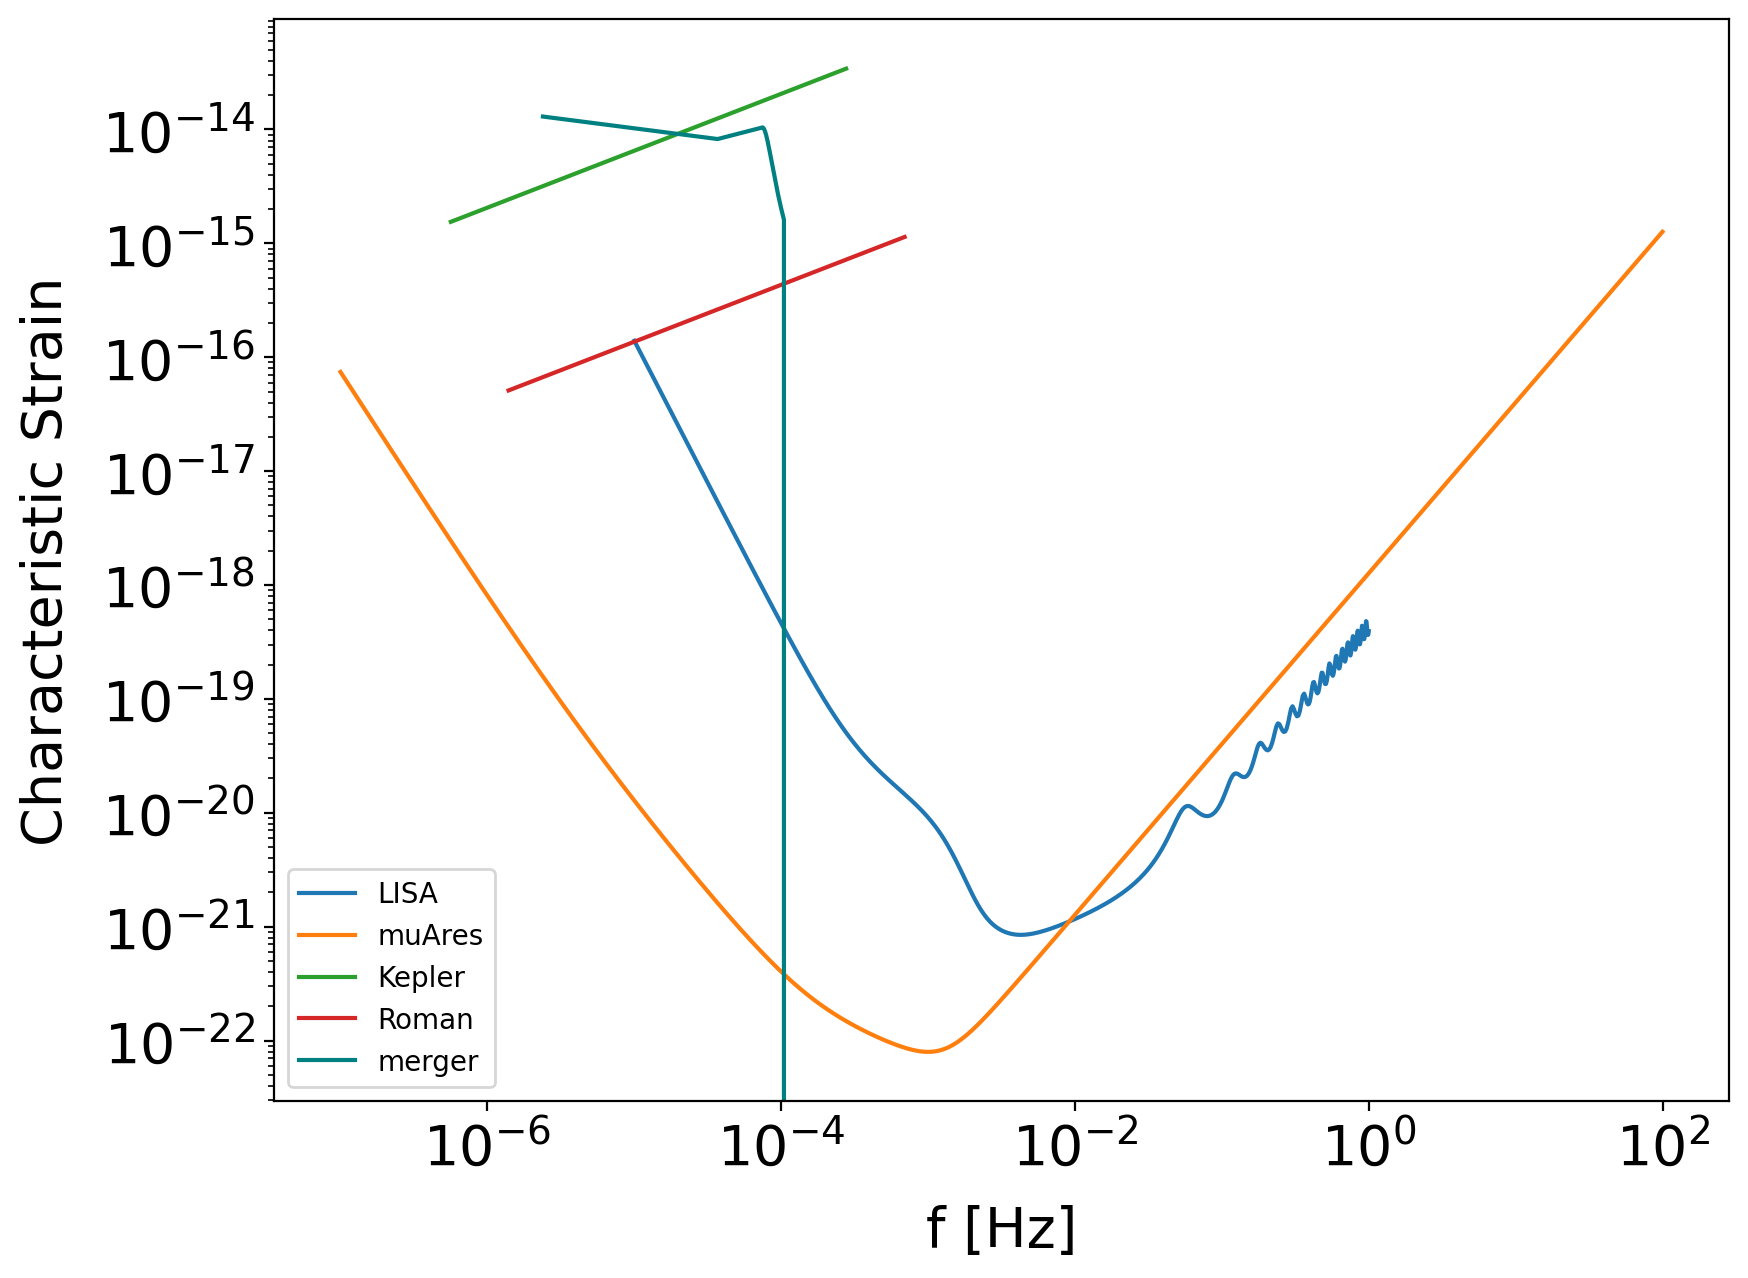

In [14]:
ax = obs.plot_multi_obs_sensitivity([lisa,muAres,kepler,roman],show=False)
binary = wt.Binary(1e8,1e8,z=0.1)
T_merge = 1*u.yr
binary.T_merge = T_merge.to(u.s)
binary.SetFreqBounds(muAres)
freqs, hc = binary.CalcStrain(muAres)
binary.add_strain_to_plot(ax, freqs, hc,color='teal',label='merger')
plt.legend()
plt.show()

In [15]:
## get multiband SNRs for a random binary
baseHP = ahp.HEALPix(16,frame='barycentricmeanecliptic')
sky_loc = baseHP.healpix_to_skycoord(850)
# skyloc = cc.SkyCoord(,frame='barycentricmeanecliptic')
binary = wt.Binary(1e8,1e8,z=0.5,sky_loc=sky_loc)

Redshift provided. 
	Luminosity Distance........... 2864.33750849413 Mpc Mpc


In [16]:
utils.assert_units(1*u.yr,u.s)

<Quantity 31557600. s>

In [17]:
snrs = {}
T_merge = 1*u.yr
for obs_i in [lisa,muAres,kepler,roman]:
    if obs_i.name == 'astrometry':
        name_i = obs_i.survey
    else:
        name_i = obs_i.name
    snrs[name_i] = binary.run_full_SNR_calc(obs_i,T_merge)
snrs['echo'] = np.sqrt(dr3like.calc_echo_snr(binary))

In [18]:
snrs

{'LISA': 604.8206043567562,
 'muAres': 11521.365464039302,
 'Kepler': 0.002032095731525974,
 'Roman': 0.09660075390103995,
 'echo': 0.007423996736452849}

In [19]:
snr2_sky, fs_sky, amps_sky = dr3like.calc_allsky_snr(binary)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3072/3072 [04:36<00:00, 11.12it/s]


<HpxMollweideAxes: title={'center': 'Echo Array SNR by GW Origin'}>

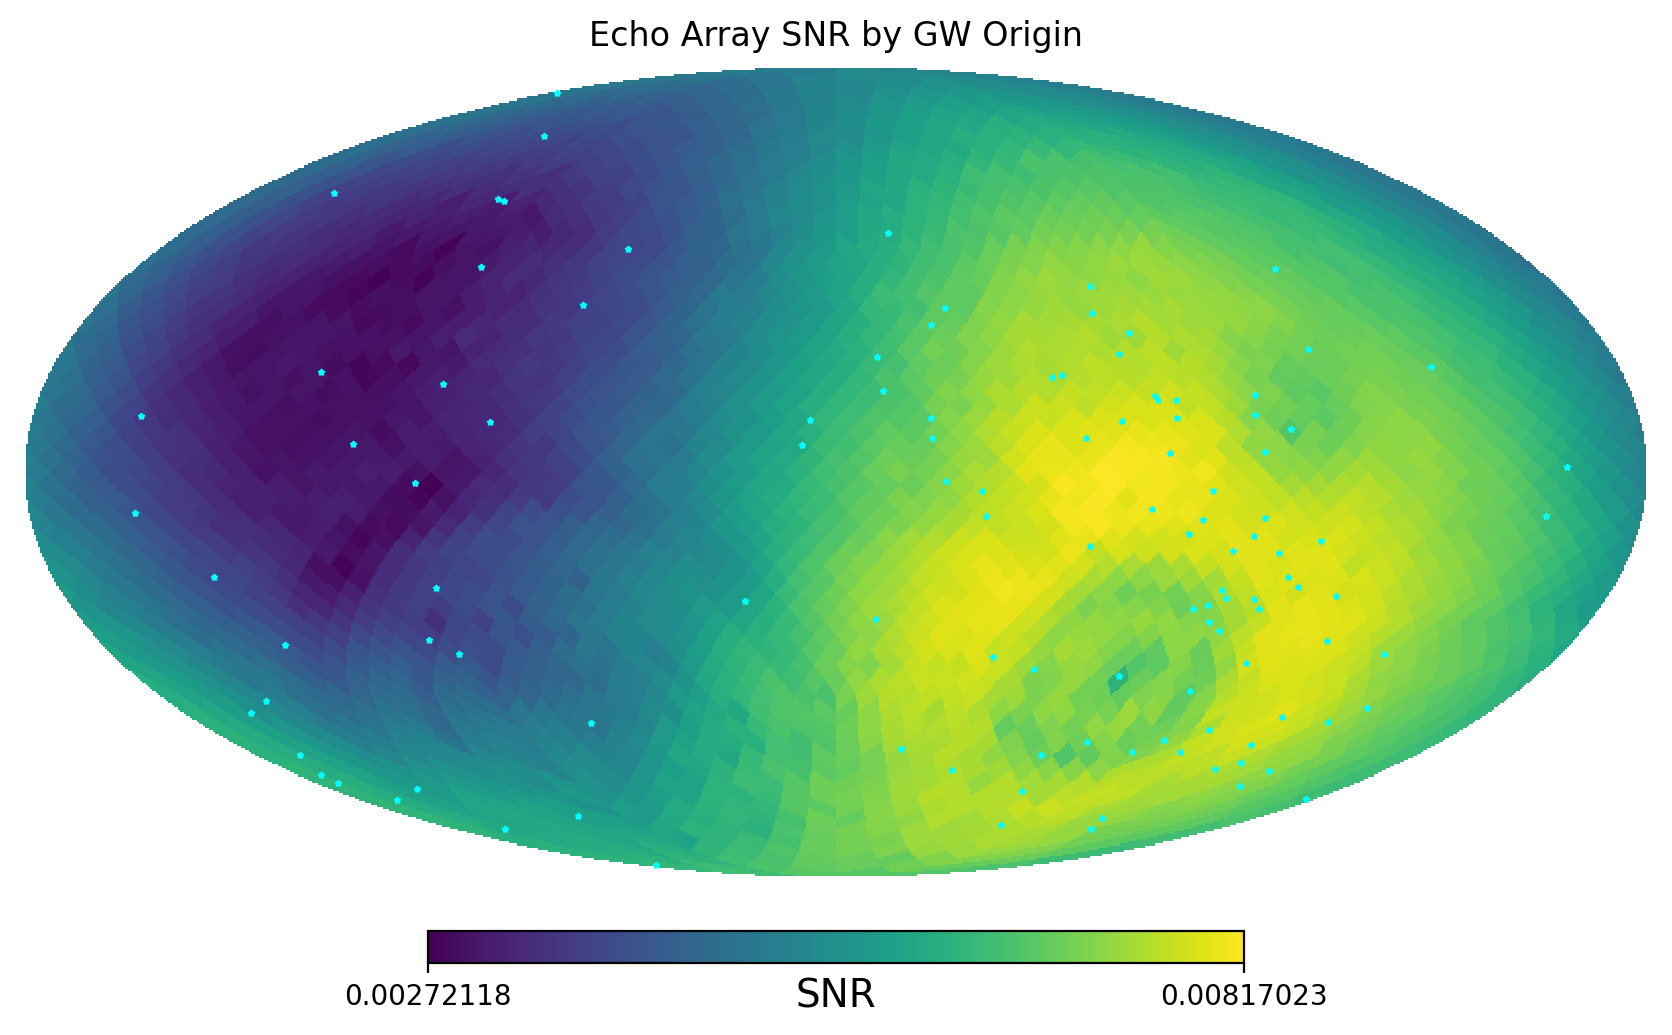

In [20]:
dr3like.plot_snr_skymap(snr2_sky,show=False)

In [52]:
## get multiband SNRs for a random binary
baseHP = ahp.HEALPix(16,frame='barycentricmeanecliptic')
sky_loc = baseHP.healpix_to_skycoord(850) ## random sky loc, will do average over sky later
## assuming equal mass ratios for now
Nm = 5
Nz = 5
T_merge = 1*obs.YEAR
Mtots = np.logspace(7,10,Nm)
zs = np.linspace(0.1,10,Nz)
snrs = {name:np.empty((Nm,Nz)) for name in [lisa.name,muAres.name,kepler.survey,roman.survey,'echo']}
for i in tqdm(range(len(Mtots))):
    for j in range(len(zs)):
        # m1 = m2 = Mtots[i]/2
        m1 = 0.5*Mtots[i].copy()
        m2 = 0.5*Mtots[i].copy()
        z = zs[j]
        for obs_i in [lisa,muAres,kepler,roman]:
            binary_i = wt.Binary(m1,m2,z=z,sky_loc=sky_loc)
            if obs_i.name == 'astrometry':
                name_i = obs_i.survey
            else:
                name_i = obs_i.name
            snrs[name_i][i,j] = binary_i.run_full_SNR_calc(obs_i,T_merge)
            snrs['echo'][i,j] = np.sqrt(dr3like.calc_echo_snr(binary_i))

  0%|                                                                                                                                                        | 0/5 [00:00<?, ?it/s]

Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 76704.342913

 20%|████████████████████████████▊                                                                                                                   | 1/5 [00:01<00:07,  1.80s/it]

Redshift provided. 
	Luminosity Distance........... 106224.87078399975 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 106224.87078399975 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.1947

 40%|█████████████████████████████████████████████████████████▌                                                                                      | 2/5 [00:03<00:05,  1.84s/it]

...

Redshift provided. 
	Luminosity Distance........... 106224.87078399975 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473

 80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                            | 4/5 [00:07<00:01,  1.82s/it]

Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 464.5786112113681 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 21543.82966123674 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 48214.19473198302 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 76704.342913

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:09<00:00,  1.83s/it]

Redshift provided. 
	Luminosity Distance........... 106224.87078399975 Mpc Mpc
Redshift provided. 
	Luminosity Distance........... 106224.87078399975 Mpc Mpc


In [53]:
snrs['LISA'].max()

71405.72961171405

In [54]:
Mtots

array([1.00000000e+07, 5.62341325e+07, 3.16227766e+08, 1.77827941e+09,
       1.00000000e+10])

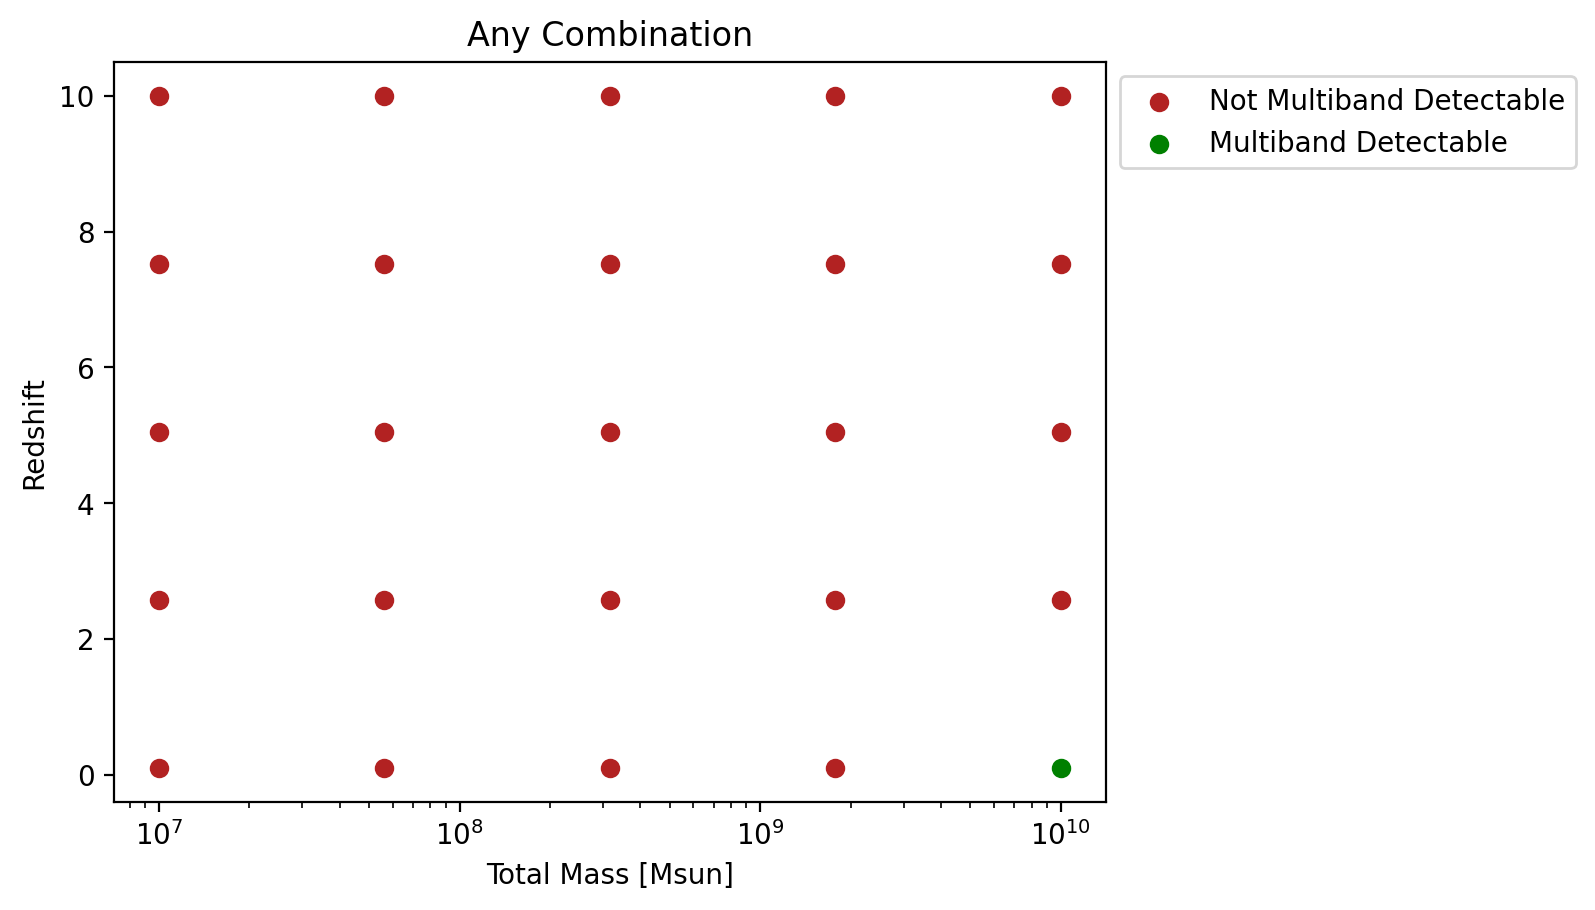

In [55]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 7
        merge_cond = np.any([snrs[name][i,j]>100 for name in [lisa.name,muAres.name,kepler.survey,roman.survey]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("Any Combination")
plt.show()

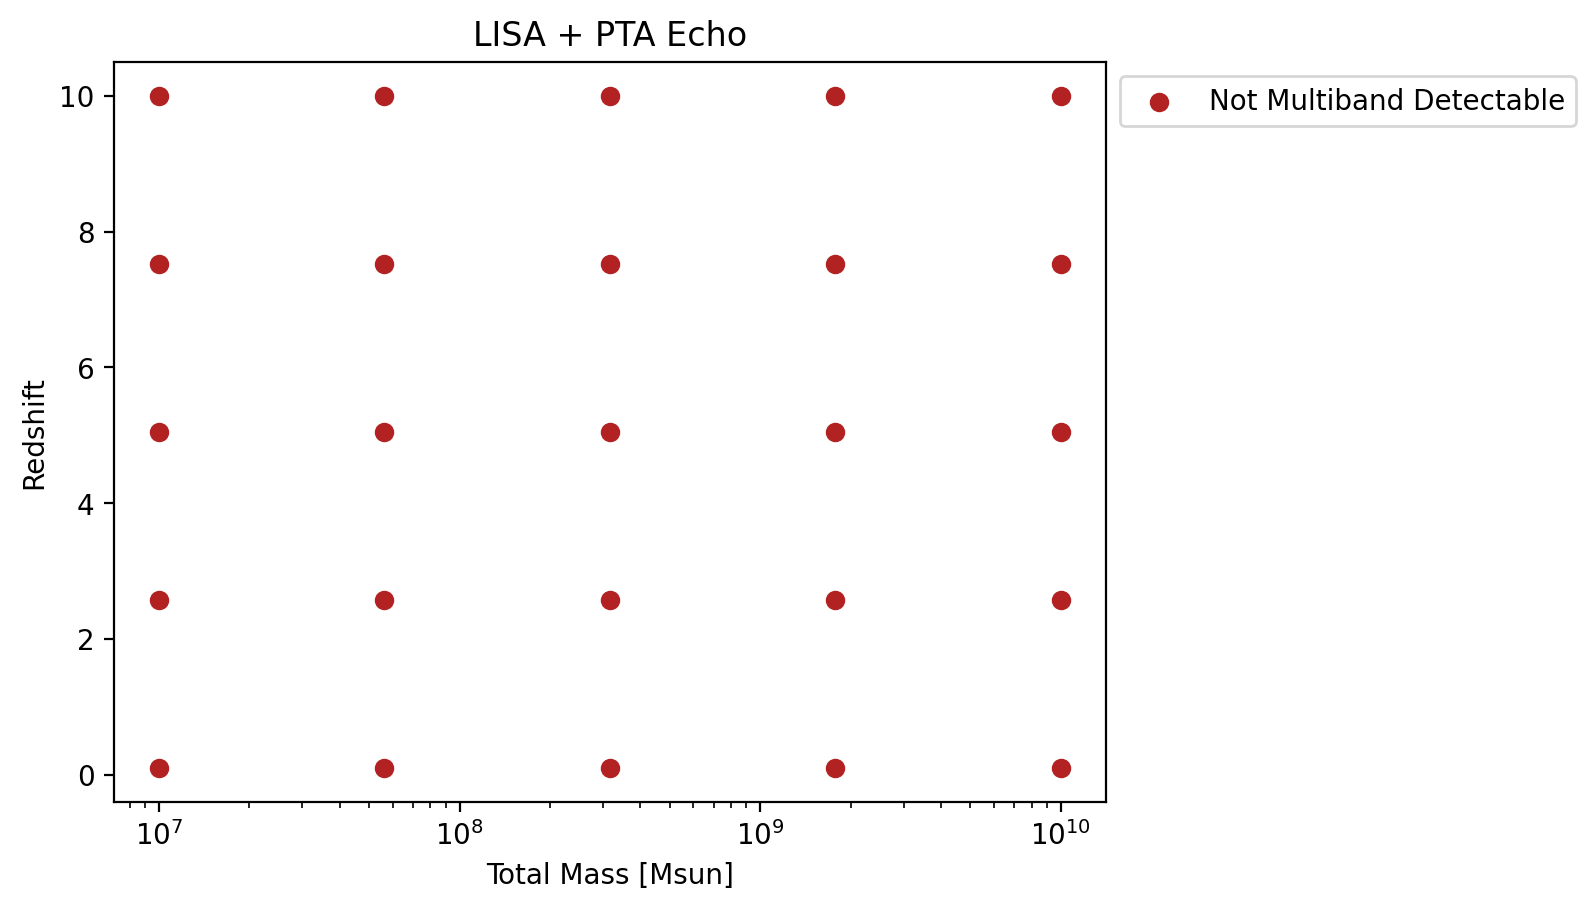

In [56]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>10 for name in [lisa.name]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("LISA + PTA Echo")
plt.show()

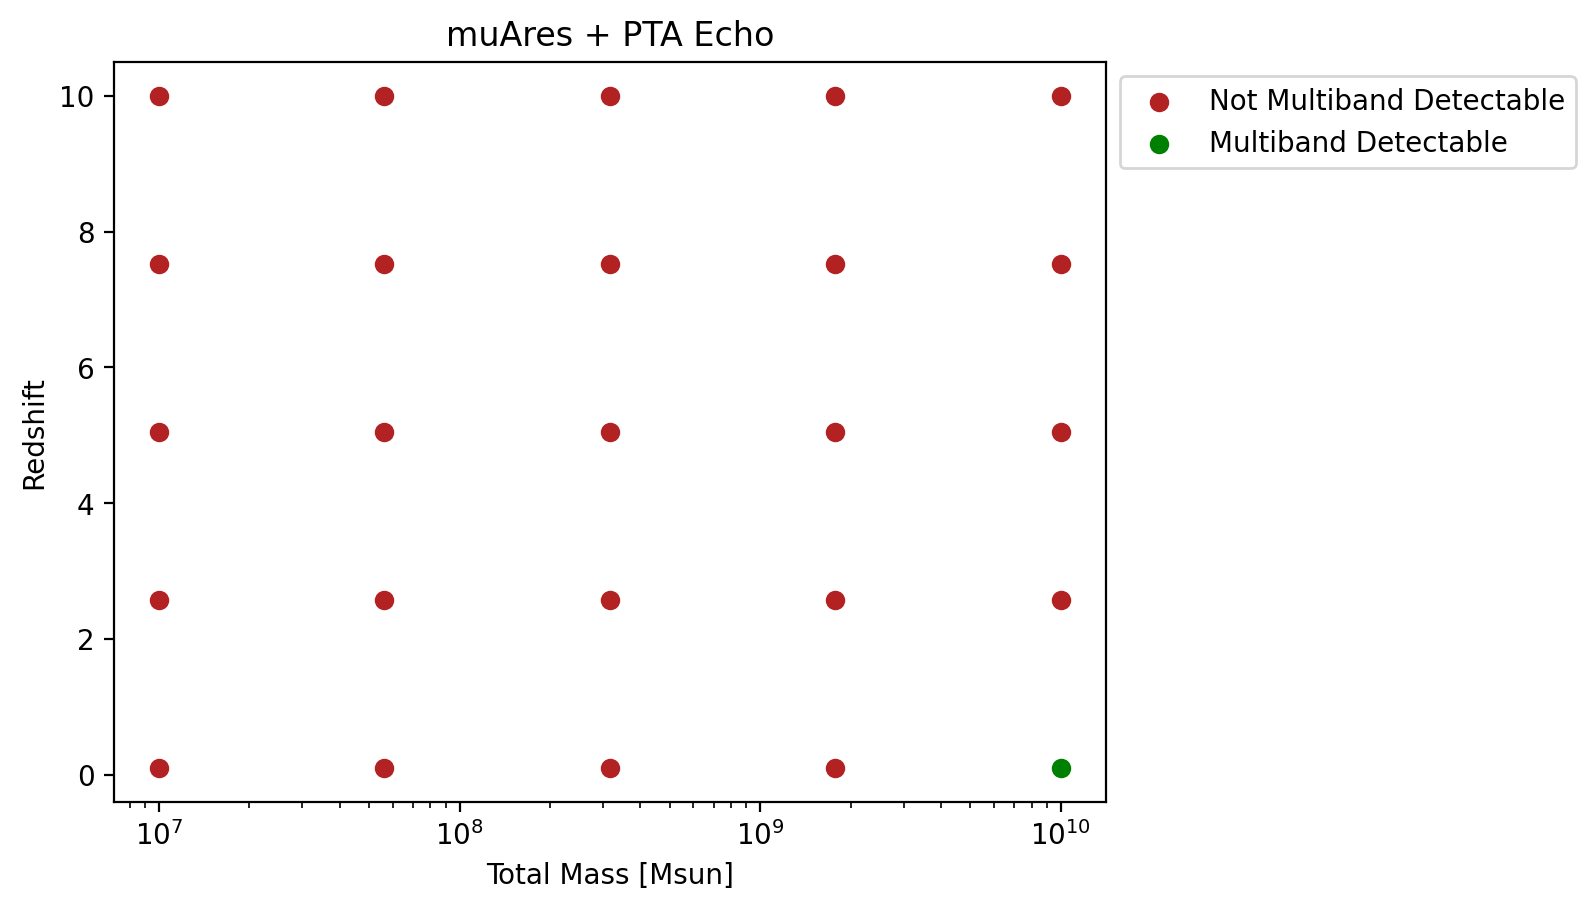

In [57]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>10 for name in [muAres.name]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("muAres + PTA Echo")
plt.show()

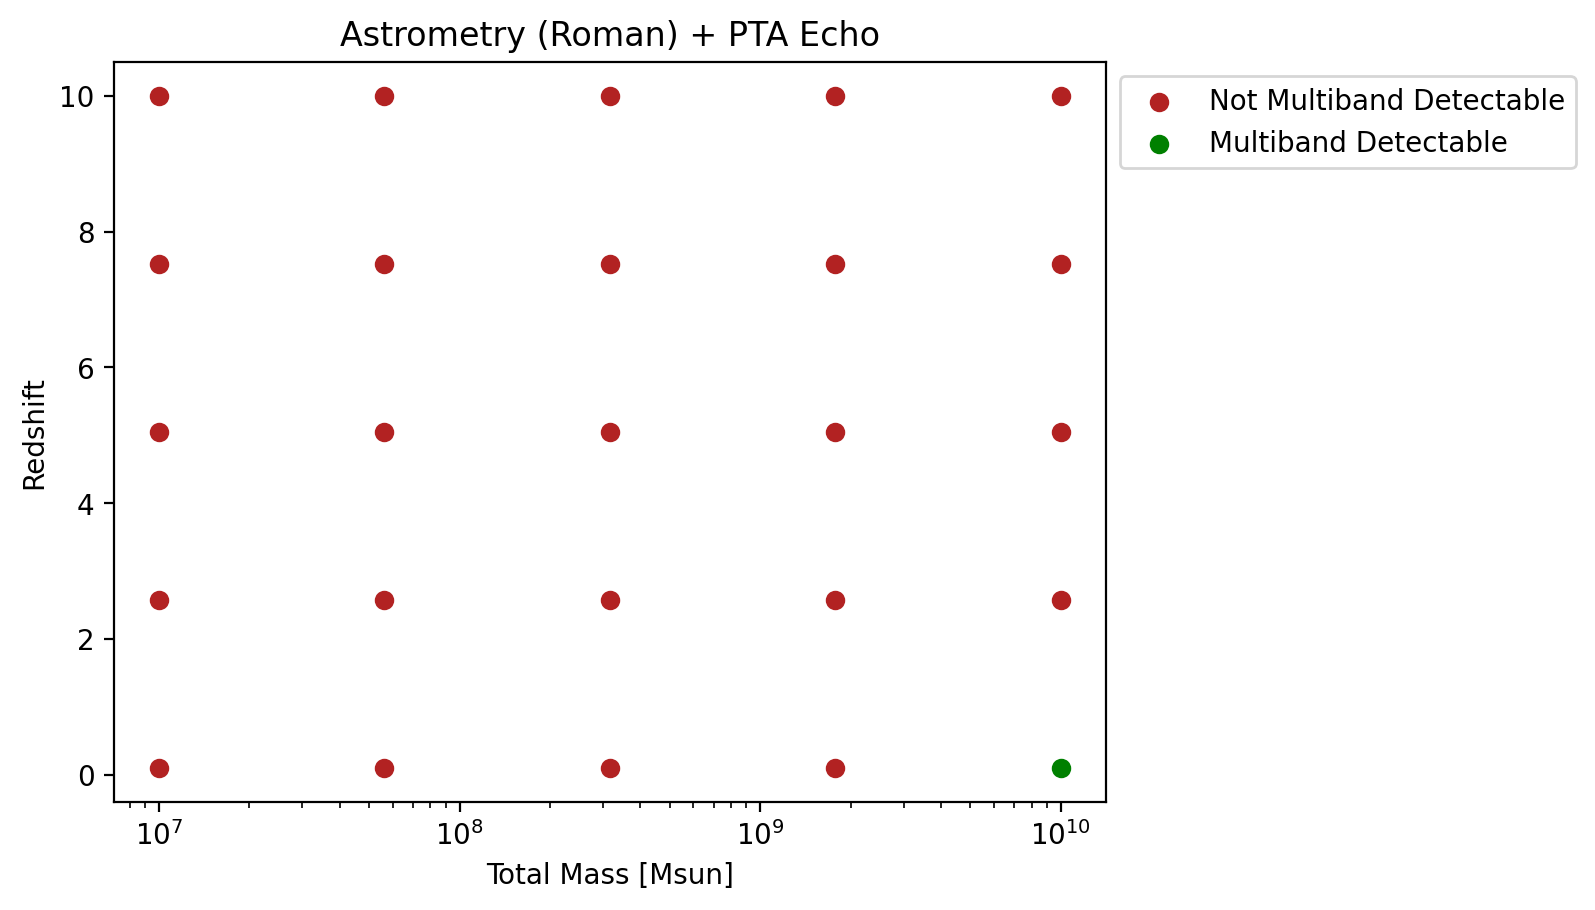

In [58]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>10 for name in [roman.survey]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("Astrometry (Roman) + PTA Echo")
plt.show()

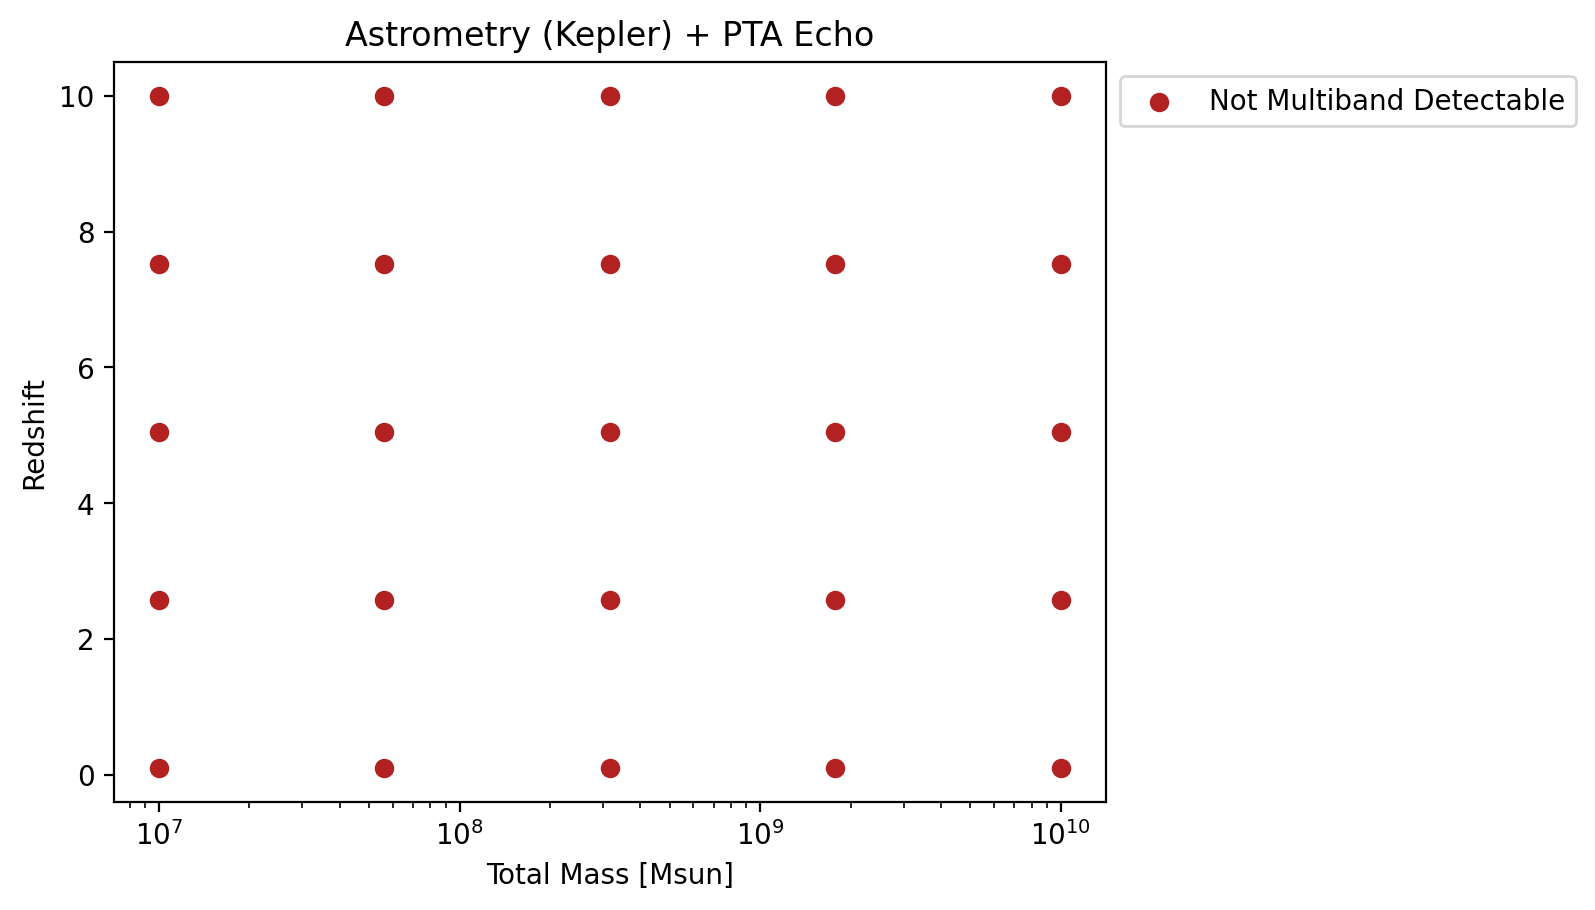

In [59]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>10 for name in [kepler.survey]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("Astrometry (Kepler) + PTA Echo")
plt.show()

SNR parameter-space "maps":

In [60]:
any_cond = np.any([snrs[name]>100 for name in [lisa.name,muAres.name,kepler.survey,roman.survey]],axis=0)

In [61]:
any_arr = np.ma.array(np.log10(snrs['echo']),mask=np.invert(any_cond),fill_value=np.nan)
single_arrs = []
names = [lisa.name,muAres.name,kepler.survey,roman.survey]
for name in names:
    cond_i = snrs[name]>100
    single_arrs.append(np.ma.array(np.log10(snrs['echo']),mask=np.invert(cond_i),fill_value=np.nan))

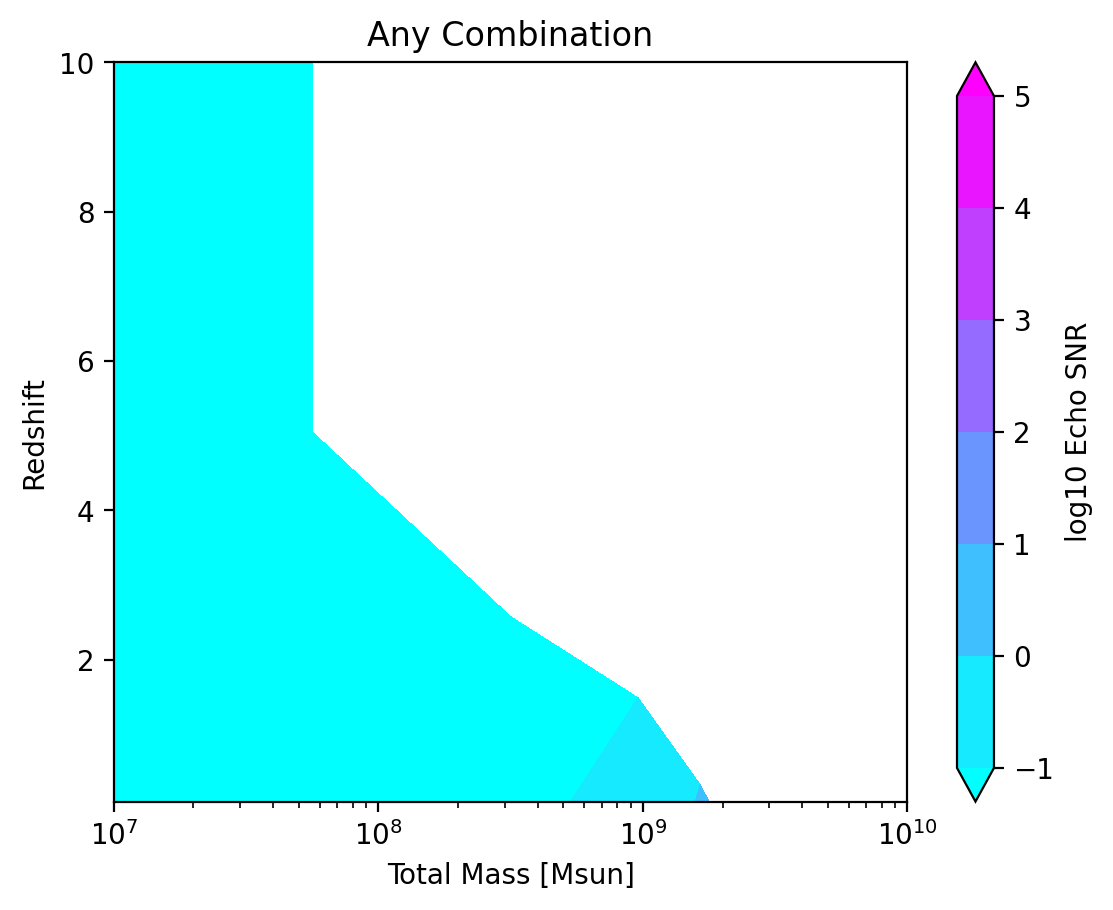

In [62]:
Mgrid, zgrid = np.meshgrid(Mtots,zs)
plt.figure()
plt.xscale('log')
plt.contourf(Mgrid.T,zgrid.T,any_arr,cmap='cool',vmin=-1,levels=[-1,0,1,2,3,4,5],extend='both')
# plt.imshow(snrs['echo'],cmap='cool',aspect='equal')
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
# plt.legend(bbox_to_anchor=(1,1))
plt.colorbar(label='log10 Echo SNR')
plt.title("Any Combination")
plt.show()

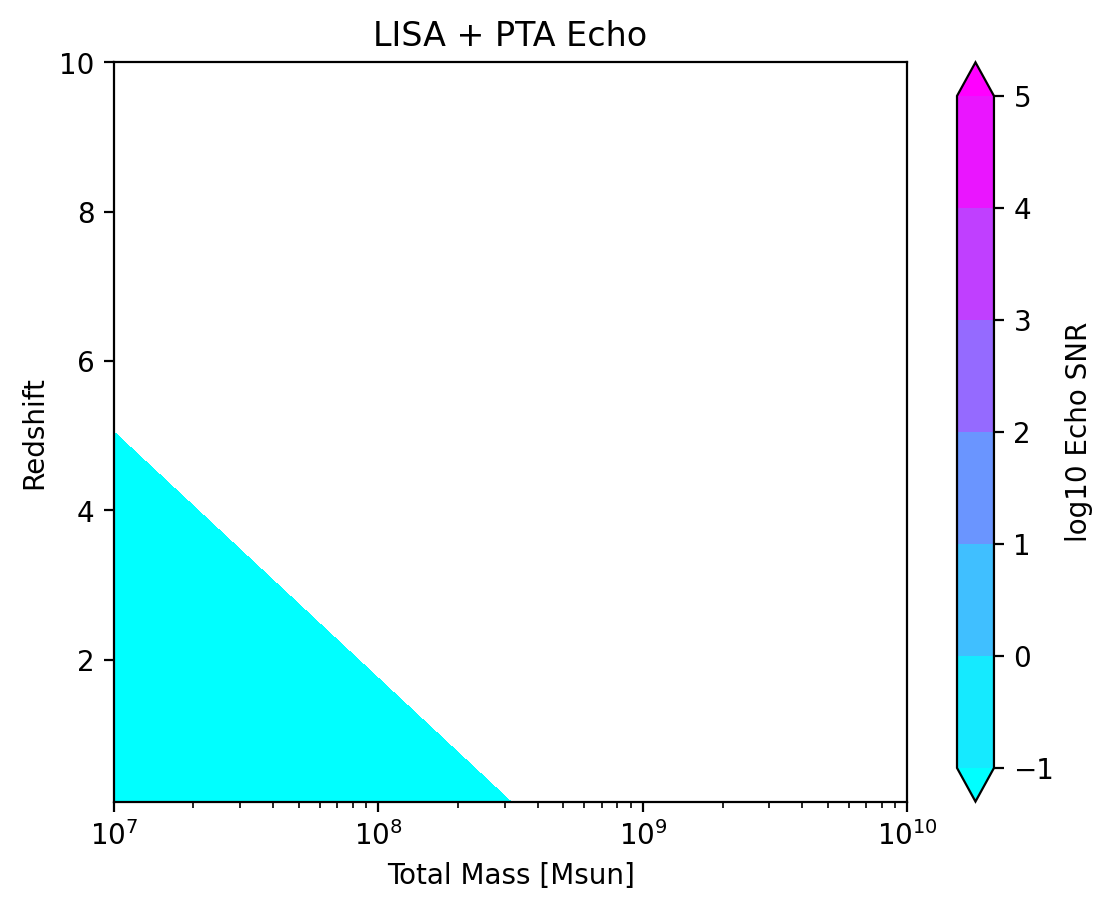

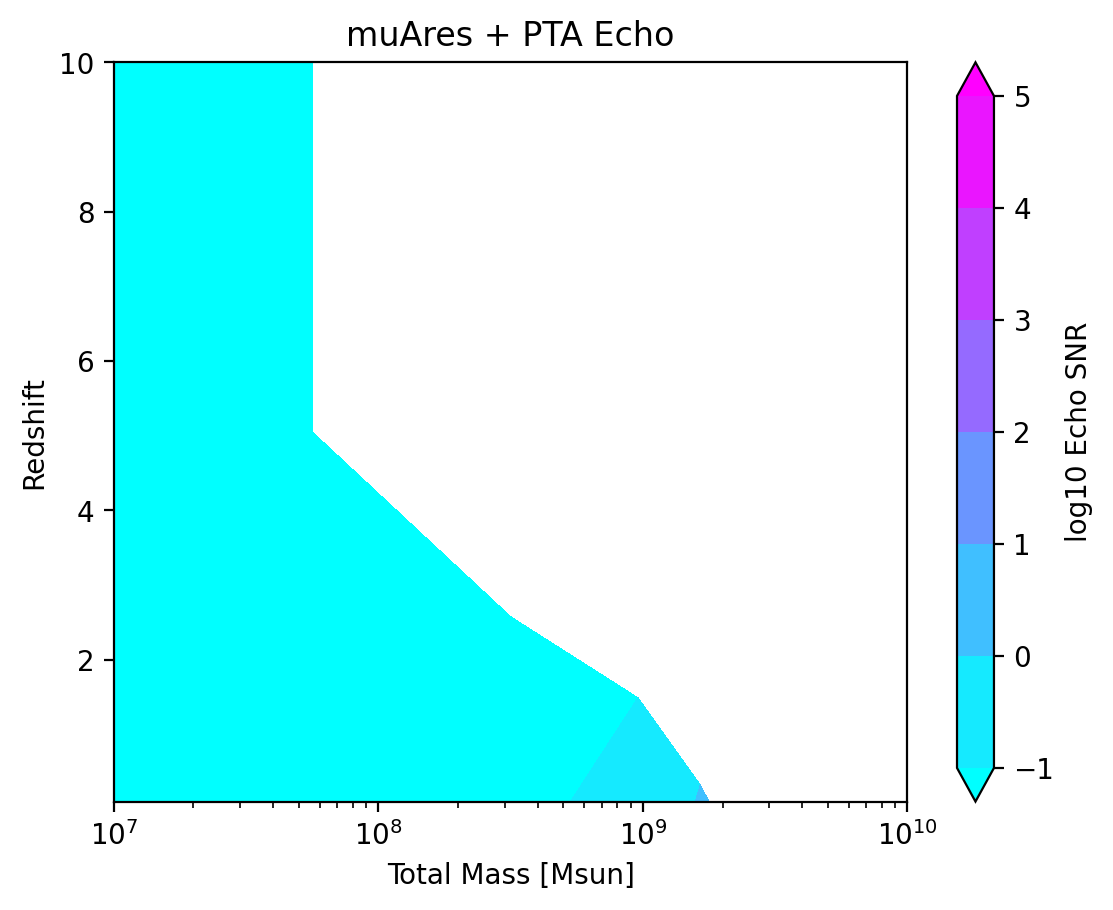

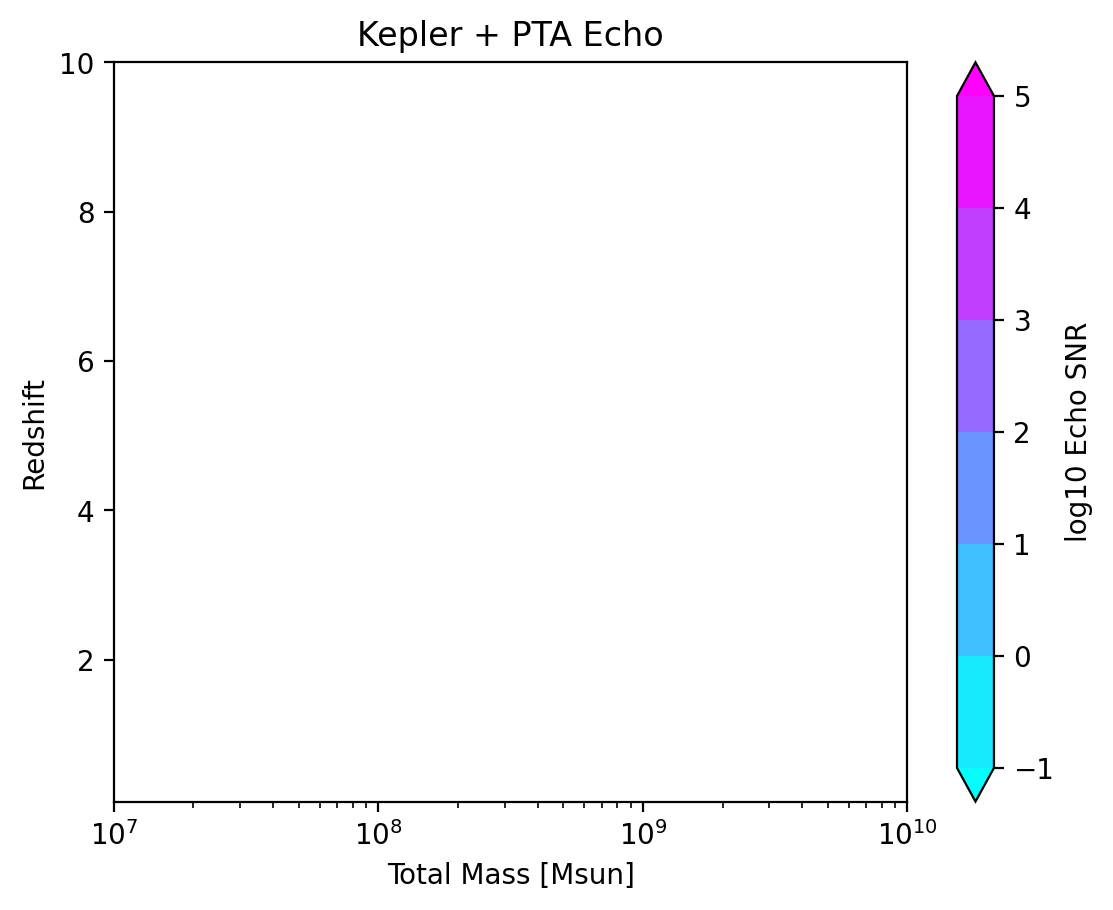

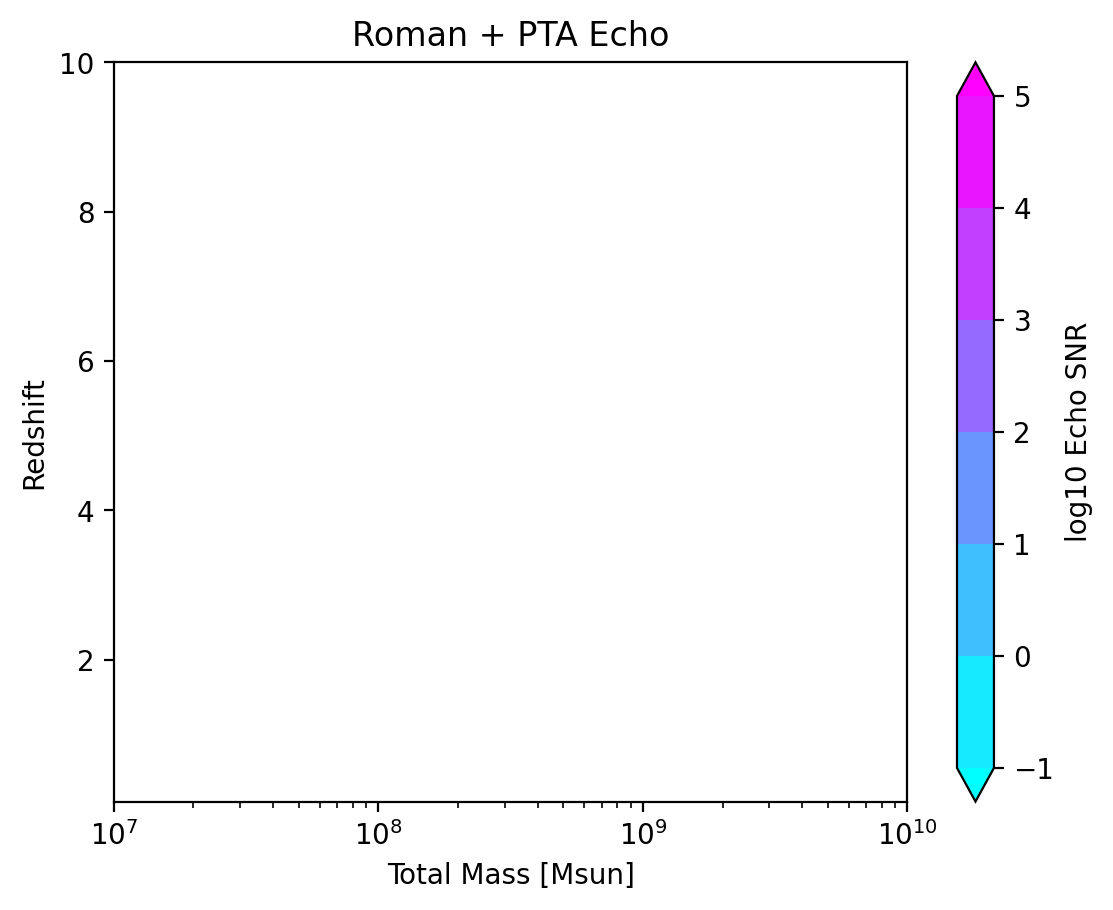

In [63]:
for i in range(len(names)):
    plt.figure()
    plt.xscale('log')
    plt.contourf(Mgrid.T,zgrid.T,single_arrs[i],cmap='cool',vmin=-1,levels=[-1,0,1,2,3,4,5],extend='both')
    # plt.imshow(snrs['echo'],cmap='cool',aspect='equal')
    plt.xlabel('Total Mass [Msun]')
    plt.ylabel('Redshift')
    # plt.legend(bbox_to_anchor=(1,1))
    plt.colorbar(label='log10 Echo SNR')
    plt.title("{} + PTA Echo".format(names[i]))
    plt.show()

/tmp/ipykernel_390116/1944160300.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.contourf(Mgrid.T,zgrid.T,np.log10(snrs[names[i]]),cmap='cool',vmin=-1)


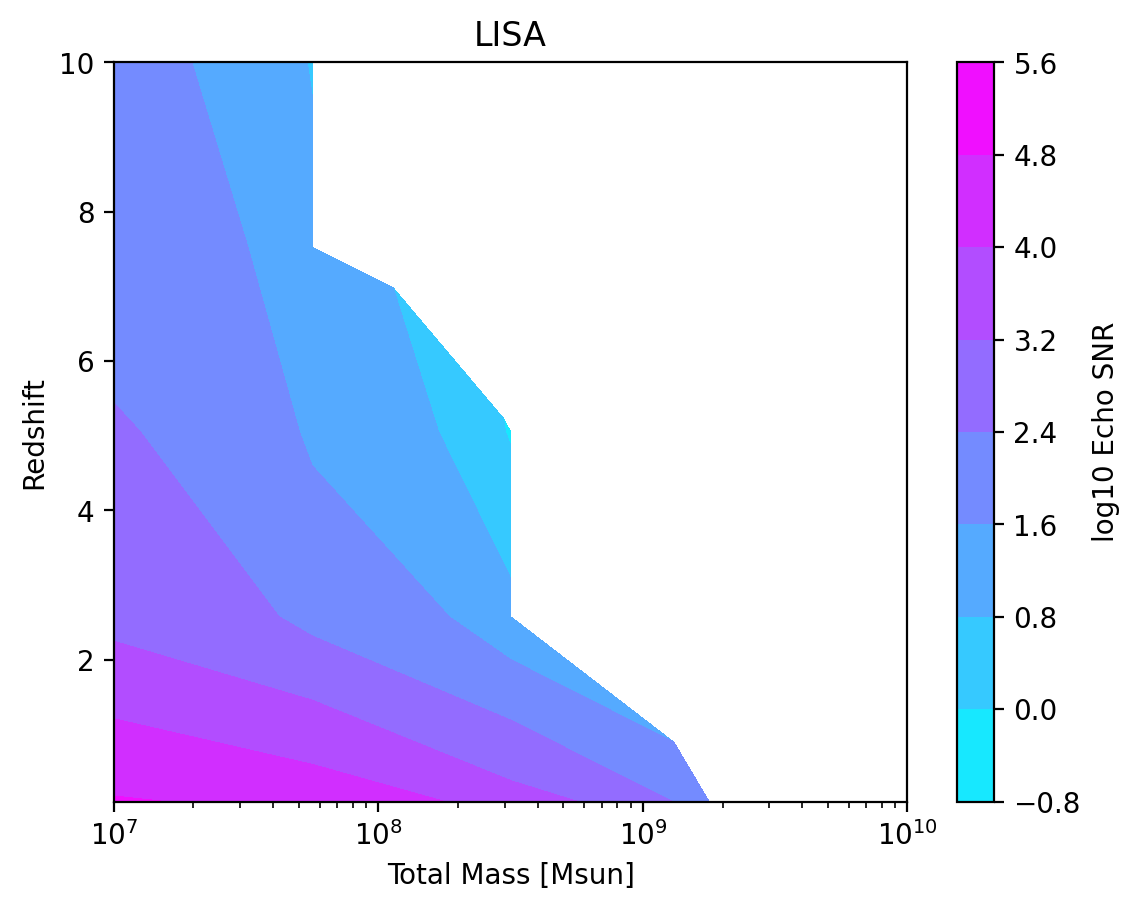

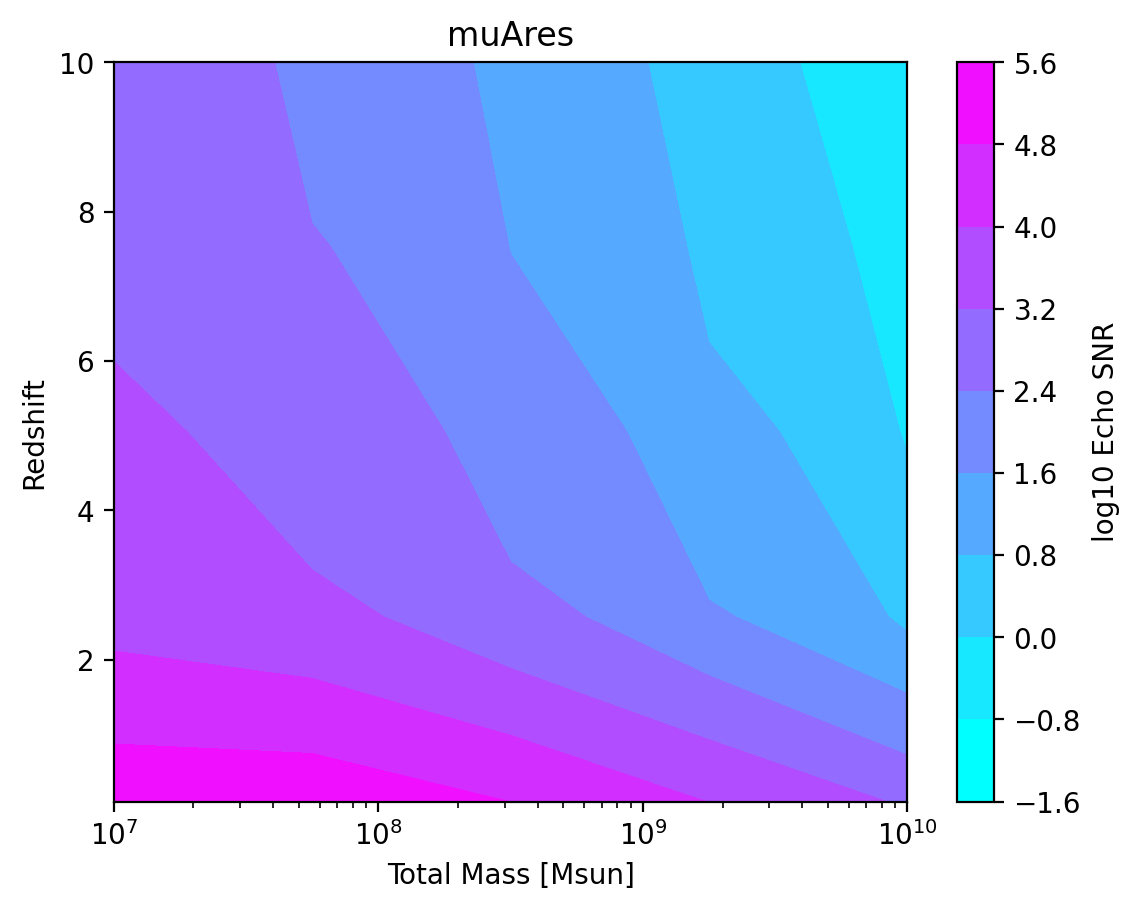

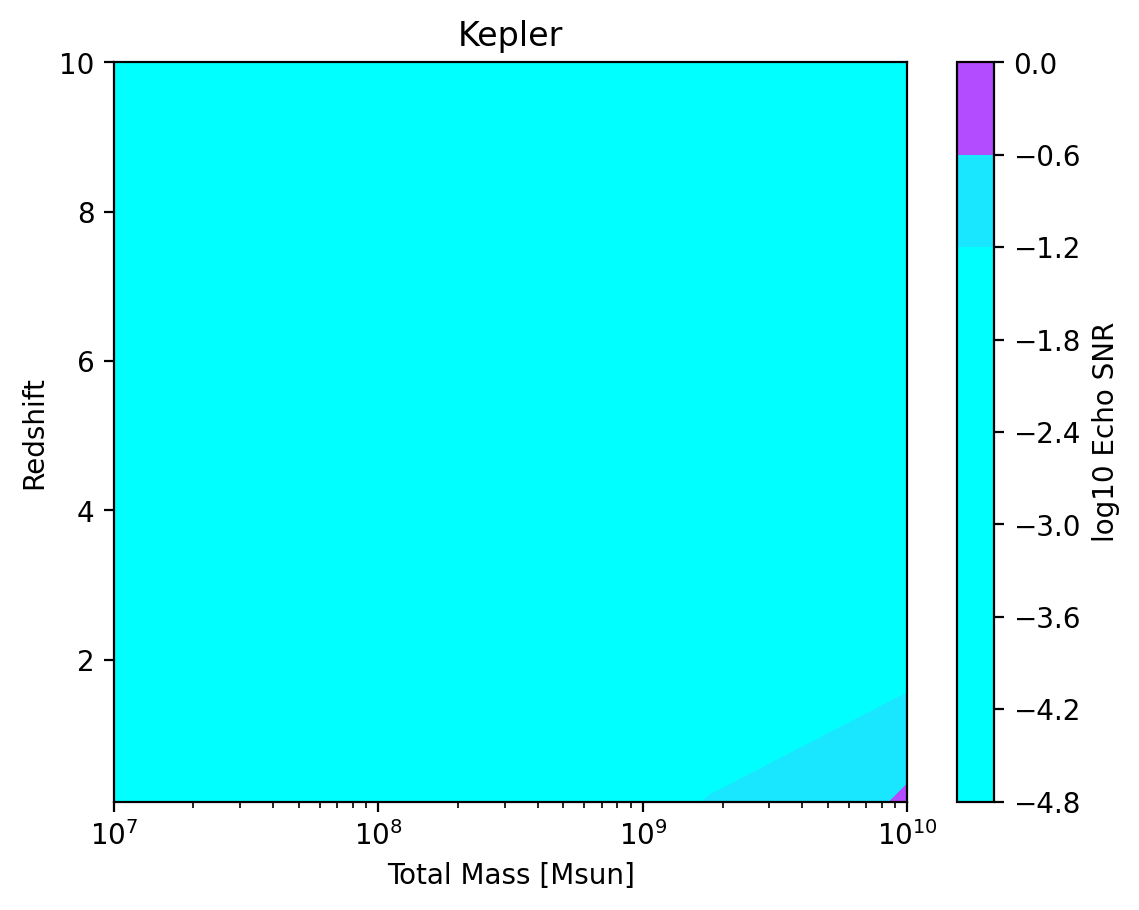

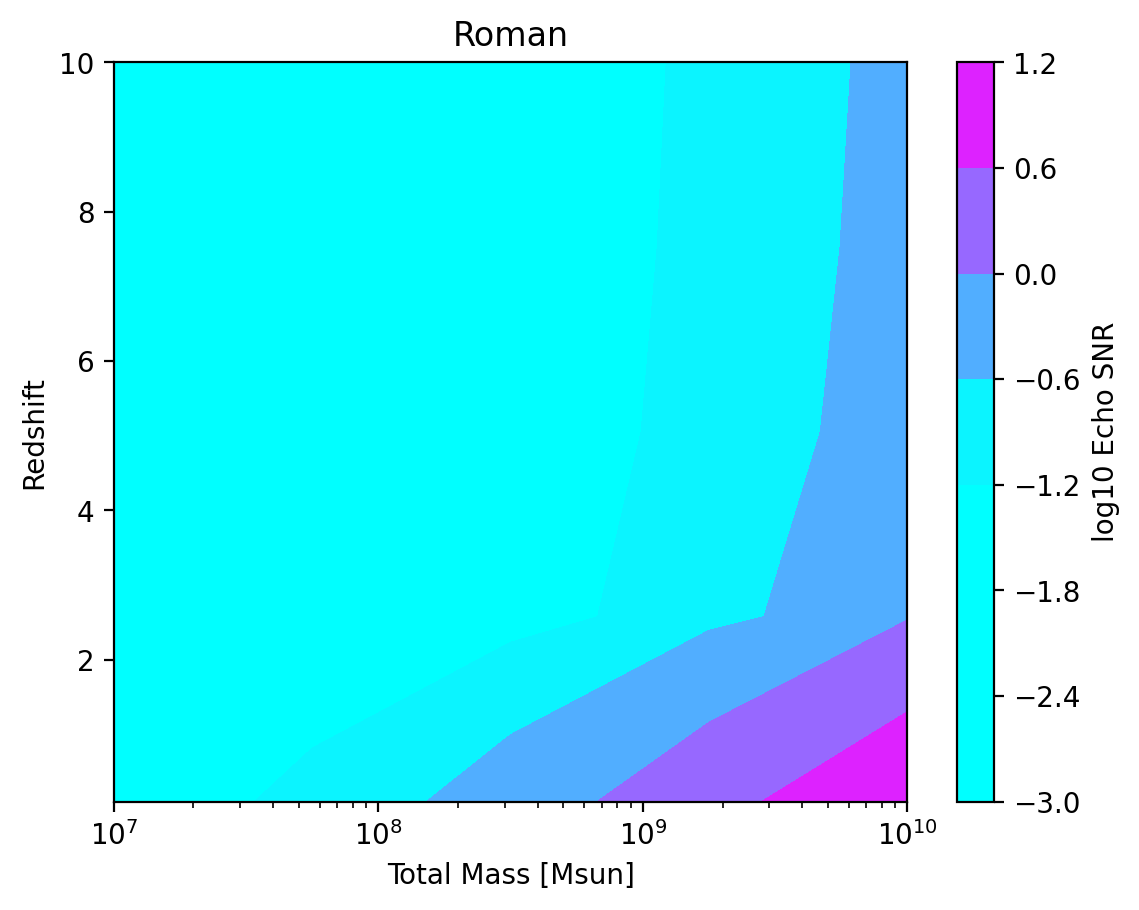

In [64]:
## check merger SNR maps
for i in range(len(names)):
    plt.figure()
    plt.xscale('log')
    plt.contourf(Mgrid.T,zgrid.T,np.log10(snrs[names[i]]),cmap='cool',vmin=-1)
    # plt.imshow(snrs['echo'],cmap='cool',aspect='equal')
    plt.xlabel('Total Mass [Msun]')
    plt.ylabel('Redshift')
    # plt.legend(bbox_to_anchor=(1,1))
    plt.colorbar(label='log10 Echo SNR')
    plt.title("{}".format(names[i]))
    plt.show()

In [46]:
pa.TSUN

4.9169e-06

In [33]:
(const.G*u.Msun/const.c**3).decompose()

<Quantity 4.92549095e-06 s>

In [34]:
np.sqrt(snrs['LISA'])

array([[19384.43877449,  6819.54711311,  4978.26845304,  4111.41745997,
         3578.96430582,  3213.03920219,  2939.50861847,  2725.6397781 ,
         2551.45665831,  2407.59314152,  2285.55789996,  2180.3341203 ,
         2089.22163676,  2007.93613535,  1934.64870217],
       [16104.01512829,  5668.08862756,  4137.9535373 ,  3417.18304011,
         2976.00868762,  2670.82195724,  2443.59802485,  2265.94619782,
         2121.54649057,  2002.04395922,  1900.67948284,  1813.77213069,
         1736.91776412,  1669.88875586,  1609.68187615],
       [14975.92627393,  5271.19449598,  3847.74660927,  3177.23390471,
         2767.12018838,  2483.42834734,  2271.87760637,  2107.08464939,
         1973.10590287,  1862.01953782,  1767.79653726,  1686.56077916,
         1615.81808838,  1552.86018995,  1496.91665624],
       [14273.19058264,  5023.17916384,  3667.23794502,  3028.11441415,
         2637.24016456,  2366.85610327,  2165.54939984,  2008.16465225,
         1880.50424507,  1774.6253975